# Fake Job Posting Detection

**Goal:** Build a machine learning system that classifies job postings as **fraudulent** or **legitimate** using both textual content (description, requirements, company profile) and structured metadata.

**Dataset:** EMSCAD (Employment Scam Aegean Dataset) — 17,880 real-world job postings, ~866 (4.8%) labeled fraudulent. Source: University of the Aegean / Kaggle ("Real or Fake Job Posting Prediction").

**Pipeline:** EDA → Preprocessing → Feature Engineering (TF-IDF vs CountVectorizer) → Modeling (Logistic Regression, Naive Bayes, Random Forest, Linear SVM) → Evaluation (accuracy, precision, recall, F1, ROC-AUC) → Comparative Analysis → Hyperparameter Tuning → Interpretation → Final Prediction System → Limitations.

In [1]:
import pandas as pd
import numpy as np
import re
import string
import warnings
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, classification_report
)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
RANDOM_STATE = 42

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

In [2]:
import os
print(os.getcwd())

d:\Downloads\3skill project\Fake Job Posting Prediction\notebooks


## 1. Data Loading

In [3]:
DATA_PATH = "../data/fake_job_postings.csv"
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
df.head(3)

Dataset shape: 17880 rows, 18 columns

Columns: ['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0


## 2. Exploratory Data Analysis

We look at class balance, missing values, and text length patterns before doing any preprocessing, since these observations directly inform our preprocessing choices later.

Class distribution:
            count  percent
fraudulent                
0           17014    95.16
1             866     4.84


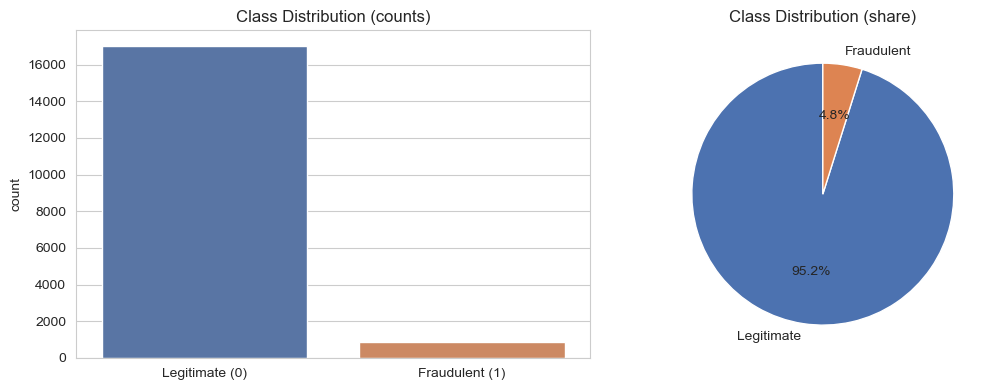

In [4]:
# Class balance
class_counts = df["fraudulent"].value_counts()
class_pct = df["fraudulent"].value_counts(normalize=True) * 100
print("Class distribution:")
print(pd.DataFrame({"count": class_counts, "percent": class_pct.round(2)}))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x="fraudulent", data=df, ax=ax[0], palette=["#4C72B0", "#DD8452"])
ax[0].set_xticklabels(["Legitimate (0)", "Fraudulent (1)"])
ax[0].set_title("Class Distribution (counts)")
ax[0].set_xlabel("")

ax[1].pie(class_counts, labels=["Legitimate", "Fraudulent"], autopct="%1.1f%%",
          colors=["#4C72B0", "#DD8452"], startangle=90)
ax[1].set_title("Class Distribution (share)")
plt.tight_layout()
plt.savefig("../figures/class_balance.png", dpi=120)
plt.show()

Missing values per column:
                     missing_count  missing_pct
salary_range                 15012         84.0
department                   11547         64.6
required_education            8105         45.3
benefits                      7212         40.3
required_experience           7050         39.4
function                      6455         36.1
industry                      4903         27.4
employment_type               3471         19.4
company_profile               3308         18.5
requirements                  2696         15.1
location                       346          1.9
description                      1          0.0


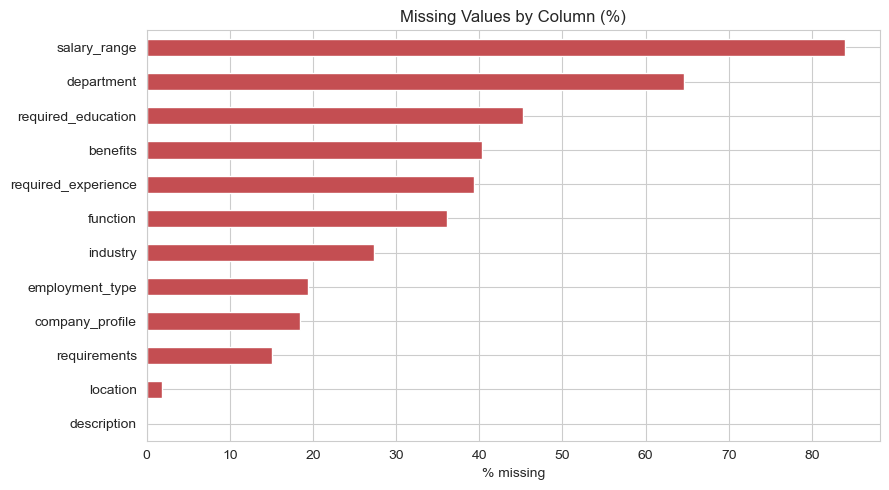

In [5]:
# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0]
print("Missing values per column:")
print(missing_df)

fig, ax = plt.subplots(figsize=(9, 5))
missing_df["missing_pct"].sort_values().plot(kind="barh", color="#C44E52", ax=ax)
ax.set_title("Missing Values by Column (%)")
ax.set_xlabel("% missing")
plt.tight_layout()
plt.savefig("../figures/missing_values.png", dpi=120)
plt.show()

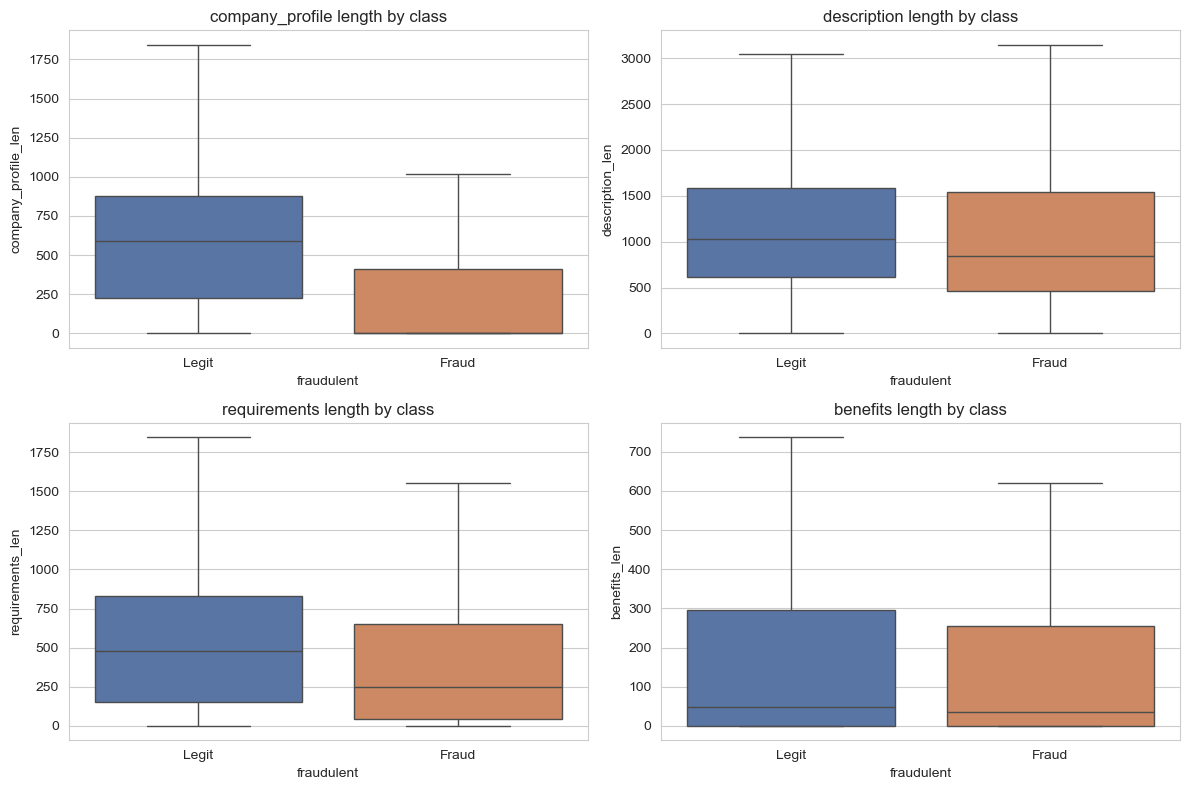

Mean text length by class:
            company_profile_len  description_len  requirements_len  benefits_len
fraudulent                                                                      
0                         640.8           1221.2             597.5         208.7
1                         230.9           1154.8             446.0         212.2


In [6]:
# Text length patterns: does fraud correlate with shorter/emptier text fields?
text_cols = ["company_profile", "description", "requirements", "benefits"]
for col in text_cols:
    df[f"{col}_len"] = df[col].fillna("").apply(len)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, text_cols):
    sns.boxplot(x="fraudulent", y=f"{col}_len", data=df, ax=ax, showfliers=False,
                palette=["#4C72B0", "#DD8452"])
    ax.set_title(f"{col} length by class")
    ax.set_xticklabels(["Legit", "Fraud"])
plt.tight_layout()
plt.savefig("../figures/text_length_by_class.png", dpi=120)
plt.show()

print("Mean text length by class:")
print(df.groupby("fraudulent")[[f"{c}_len" for c in text_cols]].mean().round(1))

In [7]:
# Structured-field indicators (logo, questions, telecommuting) vs fraud rate
for col in ["has_company_logo", "has_questions", "telecommuting"]:
    rate = df.groupby(col)["fraudulent"].mean() * 100
    print(f"\nFraud rate (%) by {col}:")
    print(rate.round(2))


Fraud rate (%) by has_company_logo:
has_company_logo
0    15.93
1     1.99
Name: fraudulent, dtype: float64

Fraud rate (%) by has_questions:
has_questions
0    6.78
1    2.84
Name: fraudulent, dtype: float64

Fraud rate (%) by telecommuting:
telecommuting
0    4.69
1    8.34
Name: fraudulent, dtype: float64


**Key EDA takeaways:**
- The dataset is heavily **imbalanced** (~95% legitimate vs ~5% fraudulent) — accuracy alone will be a misleading metric, so we rely on precision/recall/F1/ROC-AUC.
- `company_profile`, `salary_range`, `department`, and `benefits` have substantial missingness.
- Fraudulent postings tend to have **shorter or missing `company_profile`** text and are more likely to be **missing a company logo**, consistent with known scam patterns (scammers don't have a real company to describe).